In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y = iris.target

In [4]:
X_scaled = StandardScaler().fit_transform(X)

In [5]:
X.shape

(150, 4)

### Apply PCA and visualize Scree plot

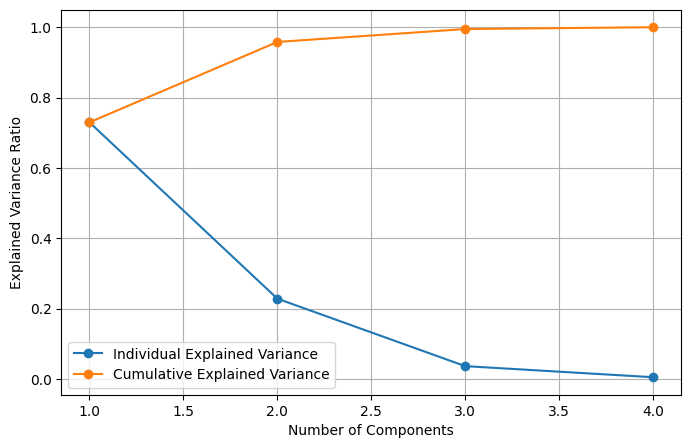

In [13]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o',label="Individual Explained Variance")
plt.plot(range(1,len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o',label="Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.legend()
plt.show()

### Choose Number of Components (95% Variance)

In [14]:
pca_95 = PCA(n_components=0.95)

X_reduces = pca_95.fit_transform(X_scaled)
print(f"Reduced Shape:{X_reduces.shape}")

Reduced Shape:(150, 2)


### Visualize Top 2 components

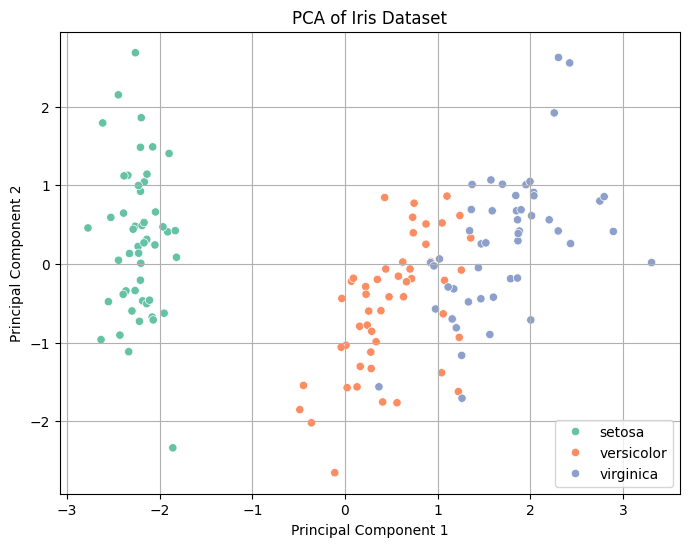

In [15]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=iris.target_names[y], palette='Set2')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid()
plt.show()